In [2]:
# 이미지 숫자 판별 예제 - CNN X, 일반 Dense layer를 이용한 방법

In [3]:
# 데이터 생성

import tensorflow as tf

# tf.keras.datasets.mnist.load_data()
# -> 데이터 로드
# -> 독립, 종속 분리
# -> 훈련, 테스트 분리

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

KeyboardInterrupt: 

In [ ]:
# 정규화

X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# 모델 설계

model = tf.keras.Sequential([
  tf.keras.Input((28, 28, 1)),
	# 블록 1
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 3
	tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	# flatten이 하는 작업을 해줌
	tf.keras.layers.GlobalAveragePooling2D(),

	# 분류기
	tf.keras.layers.Dense(256, activation='relu'),
	tf.keras.layers.Dropout(0.5),
	tf.keras.layers.Dense(10, activation='softmax')
  ])

In [ ]:
# 모델 설정
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [ ]:
#파이프 라인 
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.batch(128).prefetch(tf.data.AUTOTUNE)

# 학습 
history = model.fit(
  dataset,
  epochs = 50,
  verbose = 1
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 202ms/step - accuracy: 0.9122 - loss: 0.2815
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.9810 - loss: 0.0636
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 206ms/step - accuracy: 0.9867 - loss: 0.0454
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 168ms/step - accuracy: 0.9882 - loss: 0.0379
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - accuracy: 0.9900 - loss: 0.0320
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - accuracy: 0.9908 - loss: 0.0288
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - accuracy: 0.9925 - loss: 0.0246
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 200ms/step - accuracy: 0.9924 - loss: 0.0244
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 185ms/step - accuracy: 0.9938 - loss: 0.0202
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 182ms/step - accuracy: 0.9941 - loss: 0.0191
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - accuracy: 0.9947 - loss: 0.0171
Epoch 12/50
469/469

In [ ]:
# 평가

_ , test_acc = model.evaluate(X_test, y_test)
print(f'정확도 : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9946 - loss: 0.0252
정확도 : 0.9945999979972839


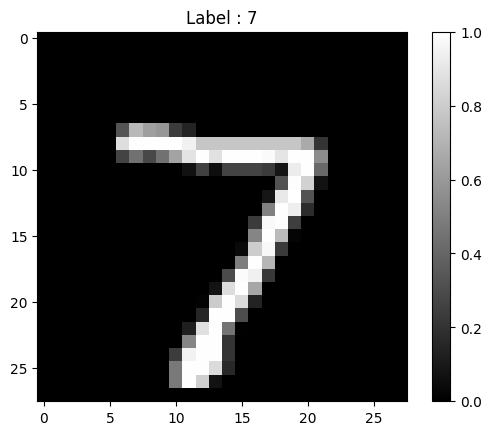

In [ ]:
# 시각화 (판별한 이미지를 보여줌), 테스트 이미지 중 0번지에 있는 이미지
import matplotlib.pyplot as plt

plt.imshow(X_test[0].reshape(28,-1), cmap = 'gray')
plt.title(f'Label : {y_test[0]}')
plt.colorbar()
plt.show()

In [ ]:
# 예측 - 훈련 데이터로 
import numpy as np
# print(X_test[0].reshape(784))
predict = model.predict(np.array([X_test[0].reshape(28, 28)]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {y_test[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
예측 숫자 : 7
실제 숫자 : 7


In [ ]:
import cv2
real_num = 6
img = cv2.imread(f'../data/img/{real_num}.png', cv2.IMREAD_GRAYSCALE)

# 전처리하기
# 테스트 이미지가 28x 28이 아니기 때문에 크기 변경

resize_img = cv2.resize(img, (28, 28))

# 이미지를 1차 배열로 변환
img_data = resize_img.flatten()

# 정규화
img_data = resize_img / 255.0
predict = model.predict(np.array([img_data]))

result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {real_num}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
예측 숫자 : 6
실제 숫자 : 6


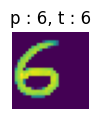

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (1, 1))

ax.imshow(img_data)
ax.set_title(f"p : {result}, t : {real_num}")
ax.axis('off')
plt.tight_layout
plt.show()

In [ ]:
# 학습한 모델 저장
model.save('cnn_mnist.keras')

In [ ]:
# 모델 불러오기 
model2 = tf.keras.models.load_model('cnn_mnist.keras')

# 예측하기
real_num = 6
img = cv2.imread(f'../data/img/{real_num}.png', cv2.IMREAD_GRAYSCALE)

# 전처리하기
# 테스트 이미지가 28x 28이 아니기 때문에 크기 변경

resize_img = cv2.resize(img, (28, 28))

# 이미지를 1차 배열로 변환
img_data = resize_img.flatten()

# 정규화
img_data = resize_img / 255.0
predict = model.predict(np.array([img_data]))

result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {real_num}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
예측 숫자 : 6
실제 숫자 : 6
